In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATASET SUPERSTORE DATA

In [ ]:
df = pd.read_csv("superstore_data.csv")
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,Id,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.149107,0.009375
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.356274,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [72]:
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0


Vì Dt_Customer là kiểu dữ liệu ngày tháng (datetime), chứa thông tin về ngày tháng đăng ký. Cta tạo cột Customer_Tenure và Chọn mốc thời gian tính tenure là ngày lớn nhất trong cột Dt_Customer. Ý nghĩa biến này hợp lý để mô hình học được mức độ gắn bó của khách với công ty.

In [73]:

# Giả sử df là dataframe của bạn
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Chọn mốc thời gian tính tenure là ngày lớn nhất trong cột Dt_Customer
max_date = df['Dt_Customer'].max()

# Tính số ngày gắn bó (tenure)
df['Customer_Tenure'] = (max_date - df['Dt_Customer']).dt.days

# Kiểm tra kết quả
print(df[['Dt_Customer', 'Customer_Tenure']].head())
df.describe()


  Dt_Customer  Customer_Tenure
0  2014-06-16              173
1  2014-06-15              174
2  2014-05-13              207
3  2014-11-05               31
4  2014-08-04              124


,Id,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Customer_Tenure
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-11 22:57:38.571428608,49.109375,303.935714,26.302232,166.950000,...,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.149107,0.009375,512.043304
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-01-08 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-19 18:00:00,24.000000,23.750000,1.000000,16.000000,...,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,340.750000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-11 00:00:00,49.000000,173.500000,8.000000,67.000000,...,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,513.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,685.250000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-12-06 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1063.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.356274,0.096391,232.229893


We also create Age from Year_Birth since it will be easier for the model to understand and process

In [74]:
# 3. Tạo biến Age từ Year_Birth
df['Age'] = 2025 - df['Year_Birth']  # hoặc năm hiện tại tùy bạn

In [75]:
df.drop(['Id', 'Dt_Customer', 'Year_Birth'], axis=1, inplace=True)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2240 non-null   object 
 1   Marital_Status       2240 non-null   object 
 2   Income               2216 non-null   float64
 3   Kidhome              2240 non-null   int64  
 4   Teenhome             2240 non-null   int64  
 5   Recency              2240 non-null   int64  
 6   MntWines             2240 non-null   int64  
 7   MntFruits            2240 non-null   int64  
 8   MntMeatProducts      2240 non-null   int64  
 9   MntFishProducts      2240 non-null   int64  
 10  MntSweetProducts     2240 non-null   int64  
 11  MntGoldProds         2240 non-null   int64  
 12  NumDealsPurchases    2240 non-null   int64  
 13  NumWebPurchases      2240 non-null   int64  
 14  NumCatalogPurchases  2240 non-null   int64  
 15  NumStorePurchases    2240 non-null   i

In [76]:
df.isnull().sum()

Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
Customer_Tenure         0
Age                     0
dtype: int64

,Total,Percent
Income,24,0.010714
Education,0,0.000000
Marital_Status,0,0.000000
Kidhome,0,0.000000
Teenhome,0,0.000000


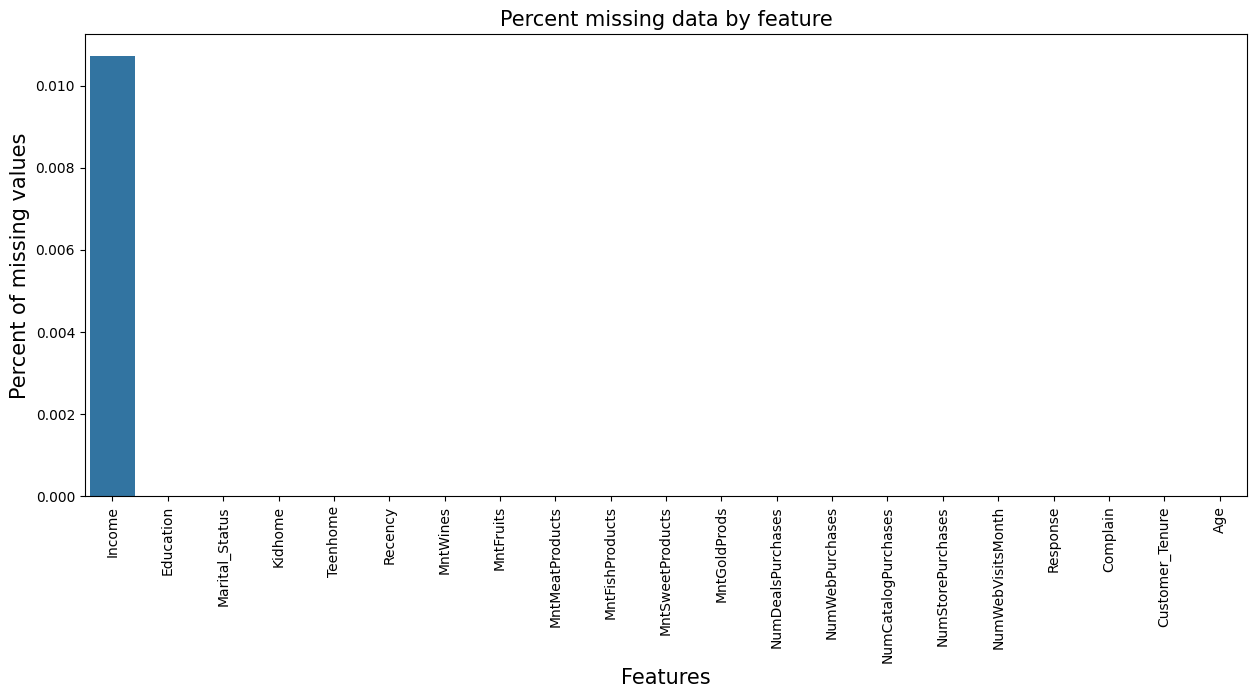

In [77]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
f, ax = plt.subplots(figsize=(15, 6))
plt.xticks(rotation=90)
sns.barplot(x=missing_data.index, y=missing_data['Percent'])
plt.xlabel('Features', fontsize=15)
plt.ylabel('Percent of missing values', fontsize=15)
plt.title('Percent missing data by feature', fontsize=15)
missing_data.head()


In [78]:
# Xóa các dòng có giá trị thiếu ở cột Income
df = df.dropna(subset=['Income']).reset_index(drop=True)
df.isnull().sum()


Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Response               0
Complain               0
Customer_Tenure        0
Age                    0
dtype: int64

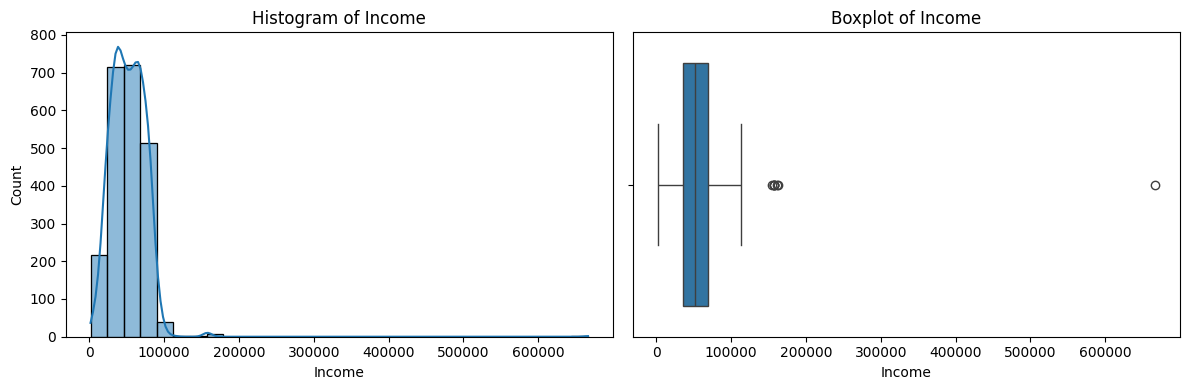

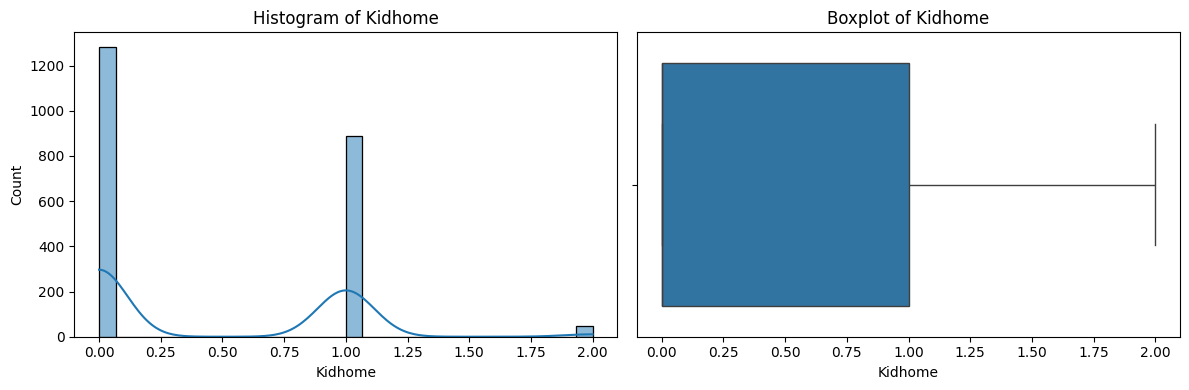

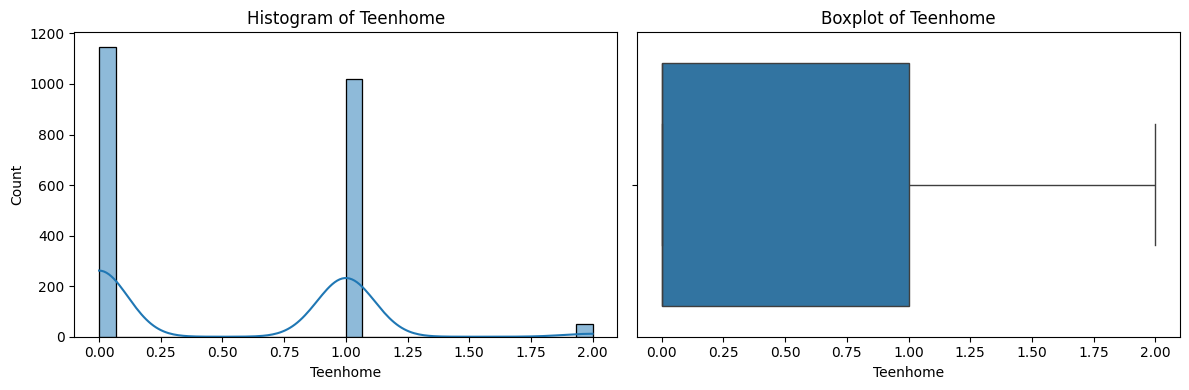

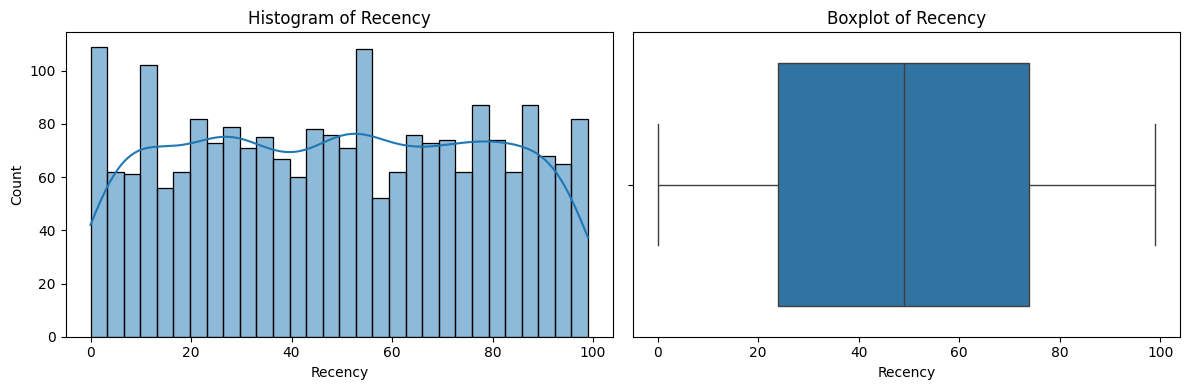

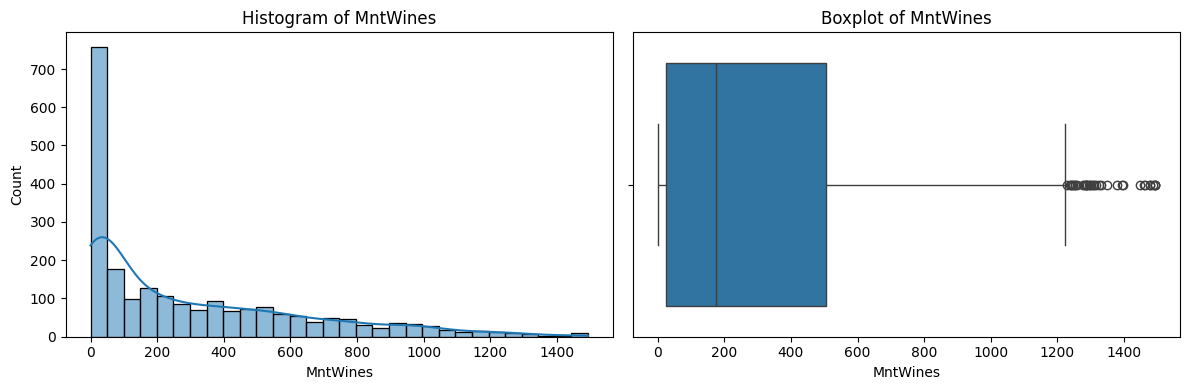

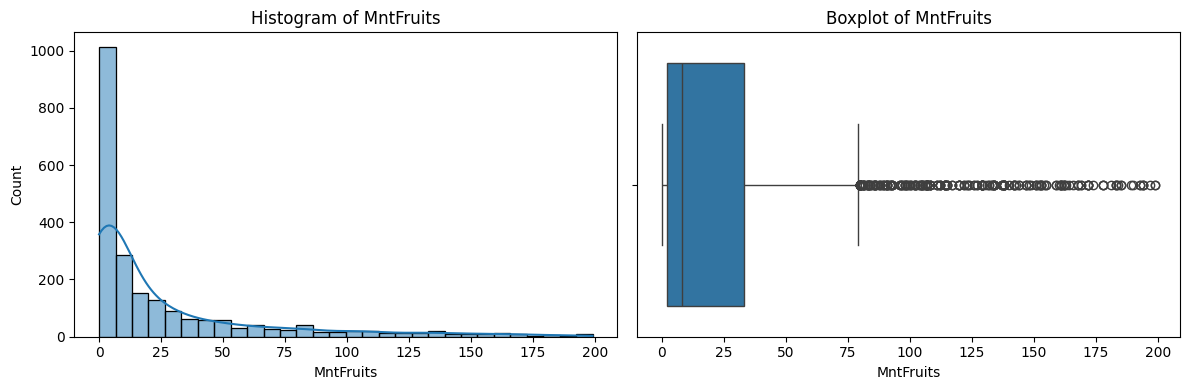

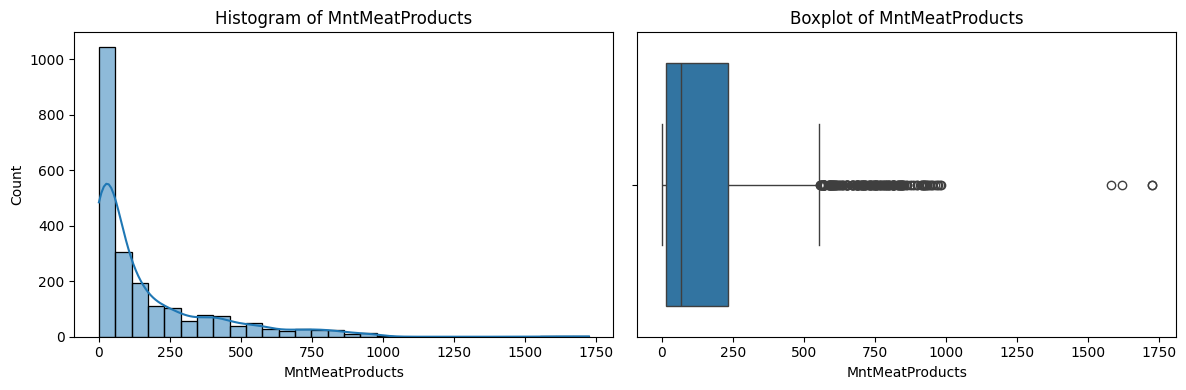

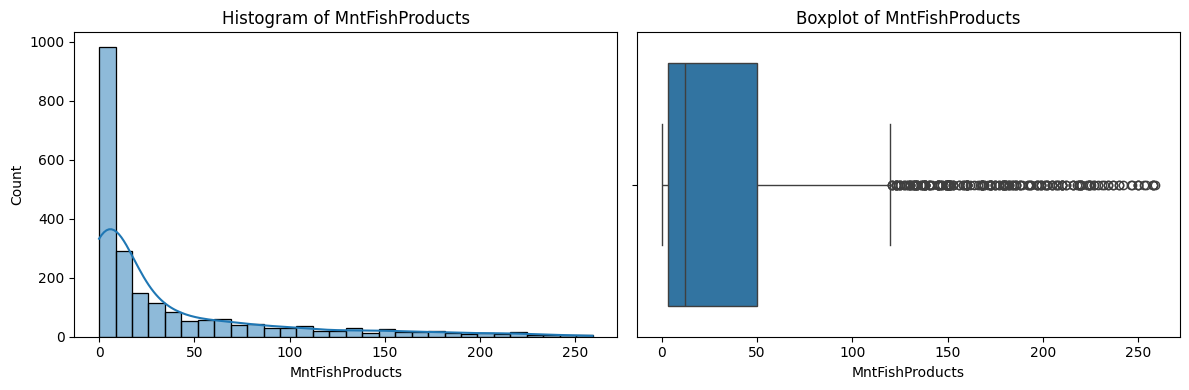

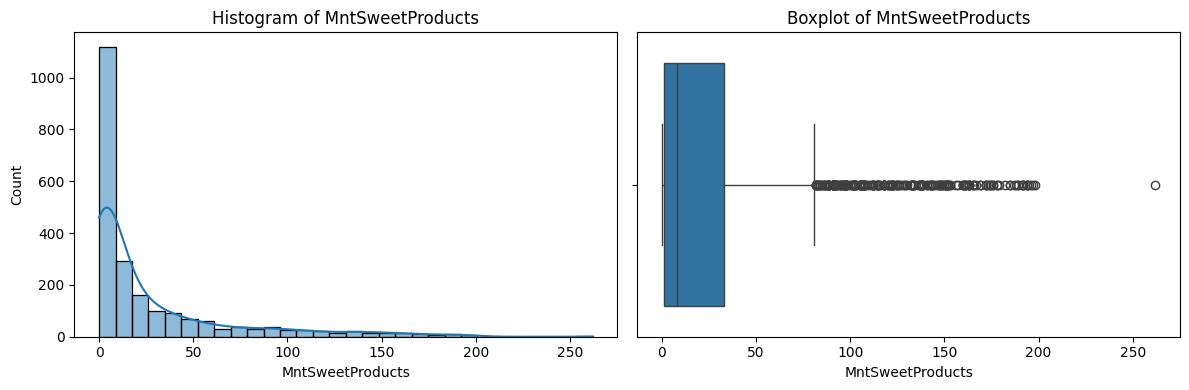

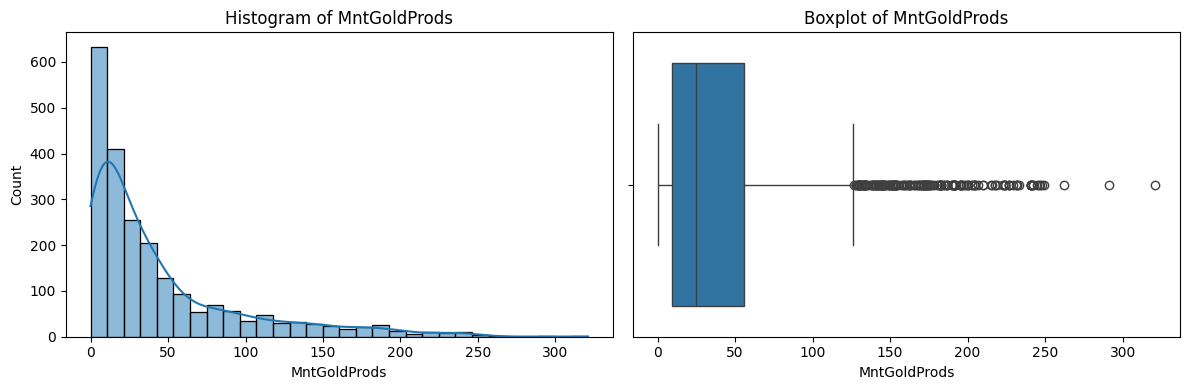

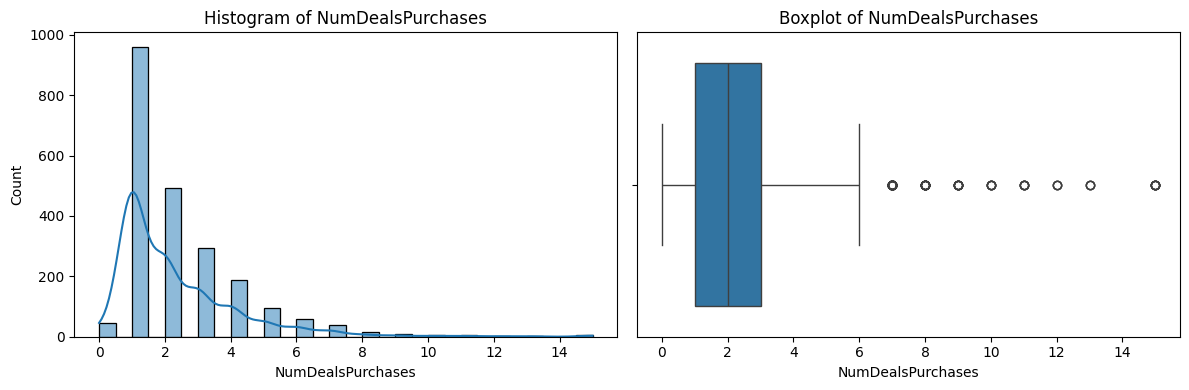

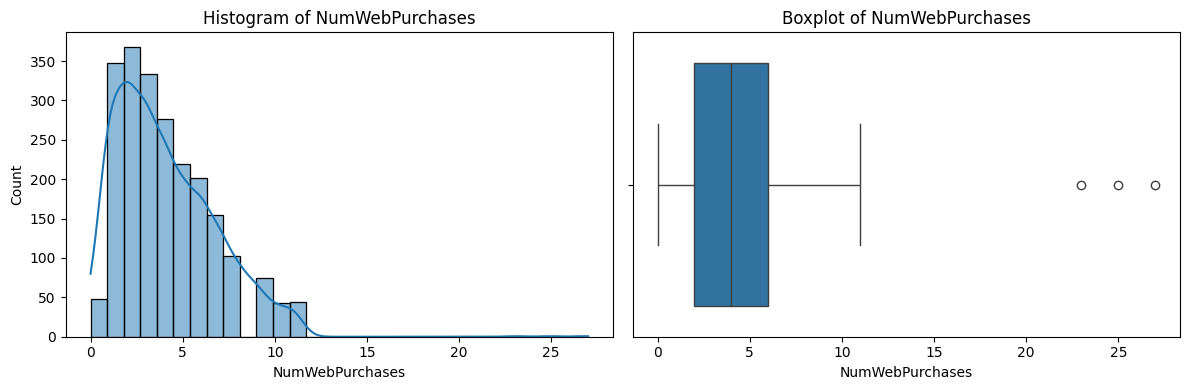

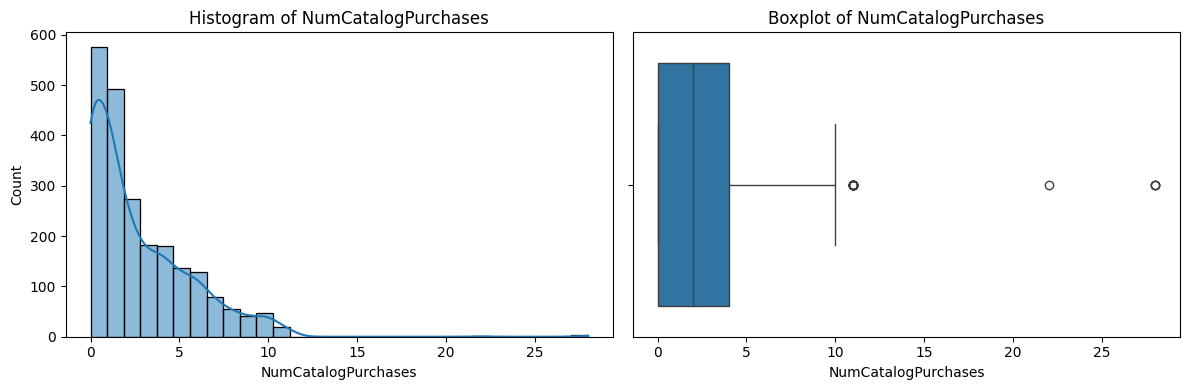

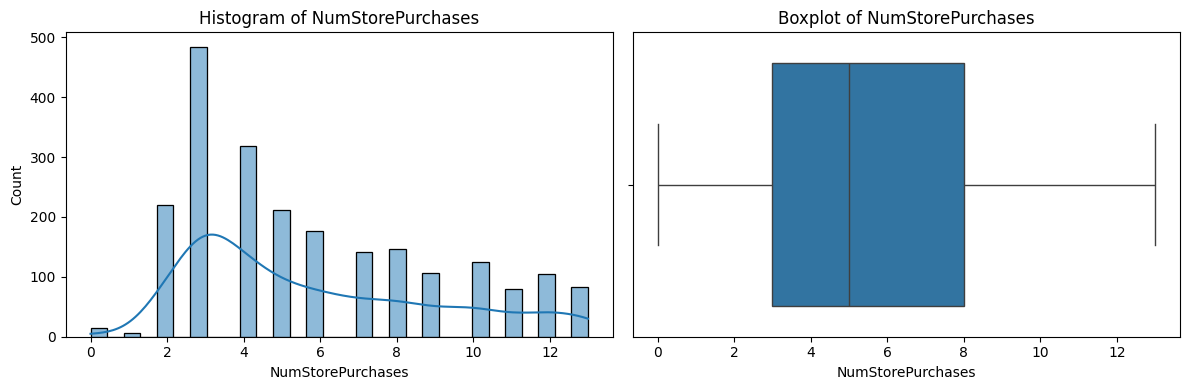

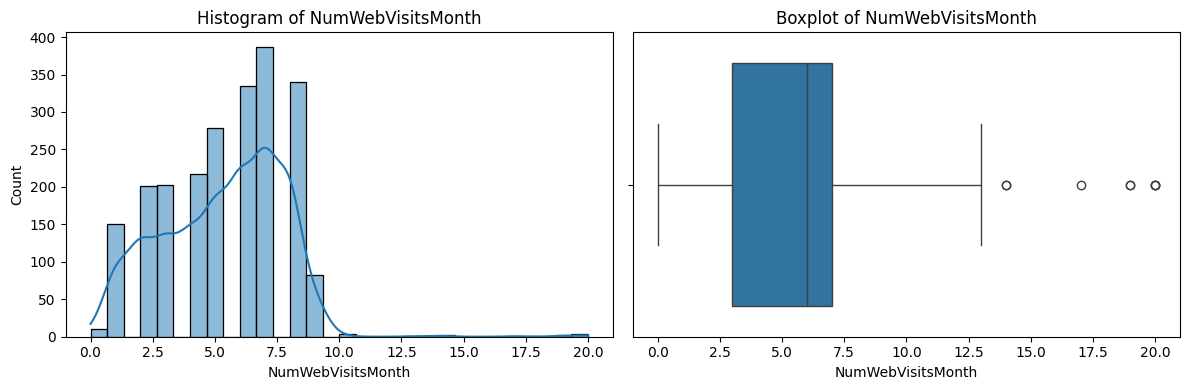

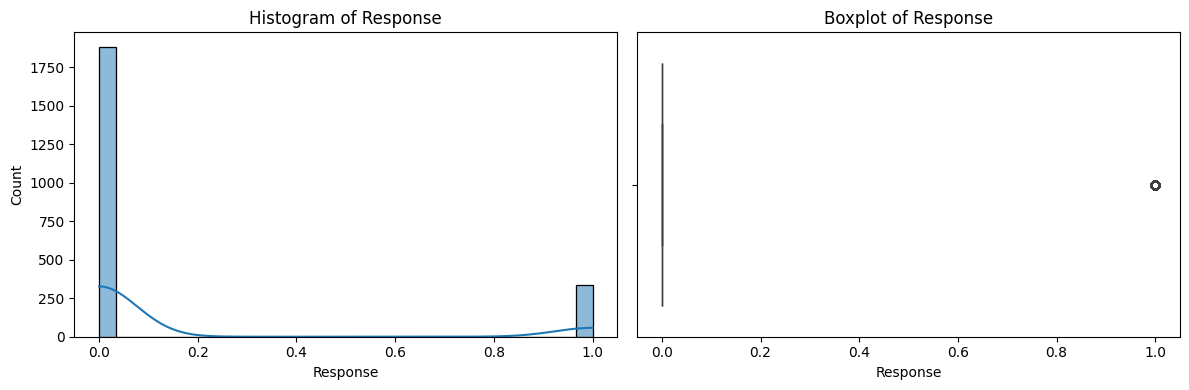

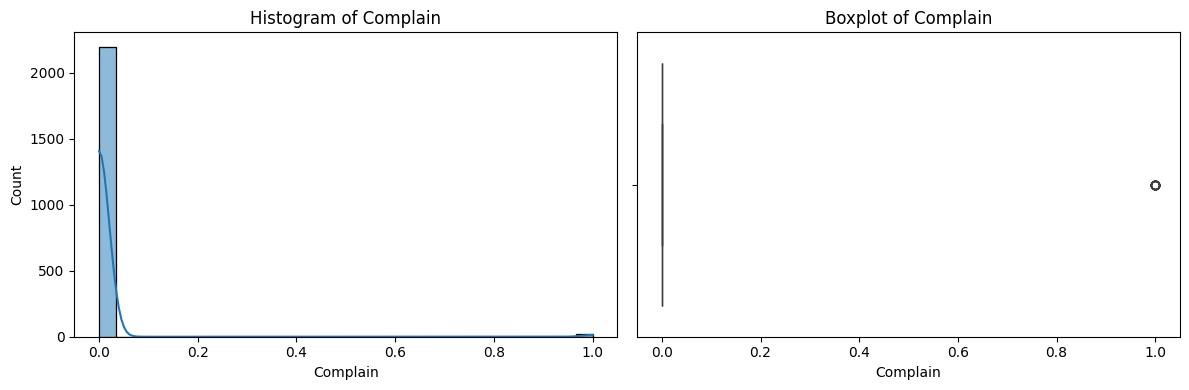

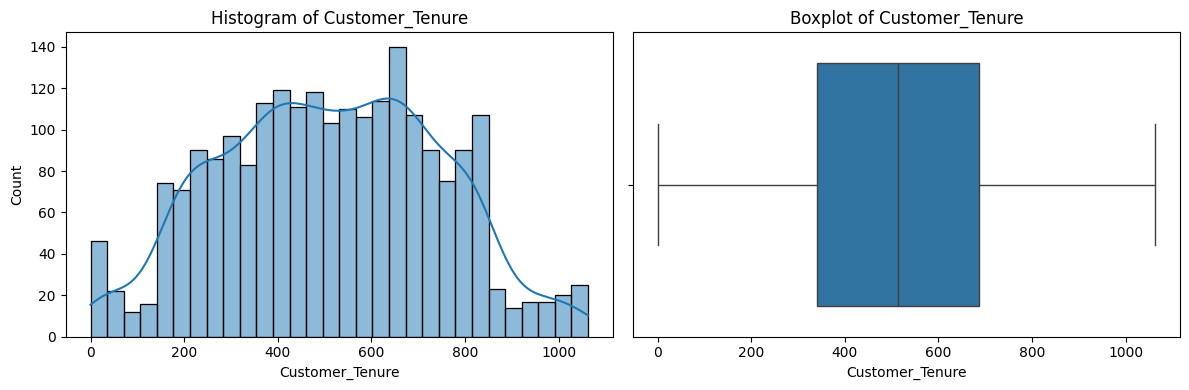

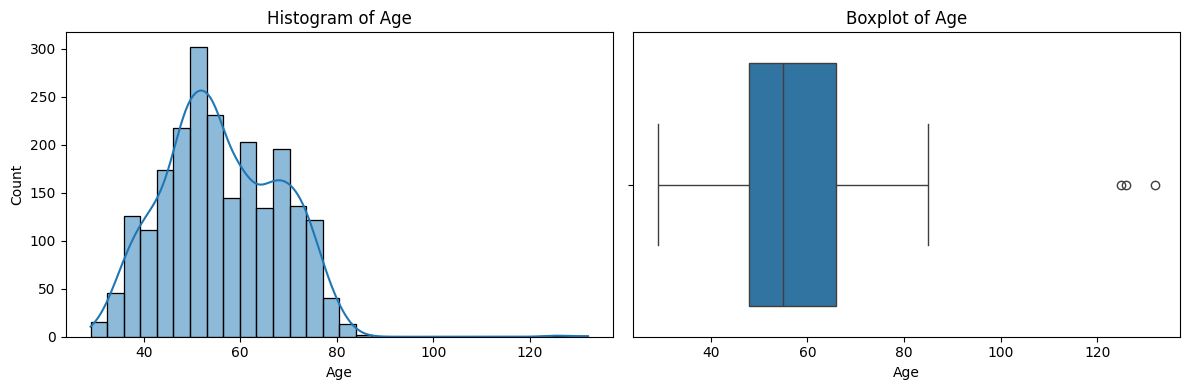

In [79]:
# Danh sách các cột numeric (float + int)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Vẽ histogram + boxplot cho từng biến numeric
for col in numeric_cols:
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()


Eliminate age > 100

In [80]:
# Kiểm tra số dòng ban đầu
print(f"Số dòng trước khi lọc: {len(df)}")

# Lọc giữ lại các dòng có residential_assets_value >= 0
df_cleaned = df[df['Age'] <= 100].copy()

# Kiểm tra số dòng sau khi lọc
print(f"Số dòng sau khi loại bỏ Age > 100: {len(df_cleaned)}")



Số dòng trước khi lọc: 2216
Số dòng sau khi loại bỏ Age > 100: 2213


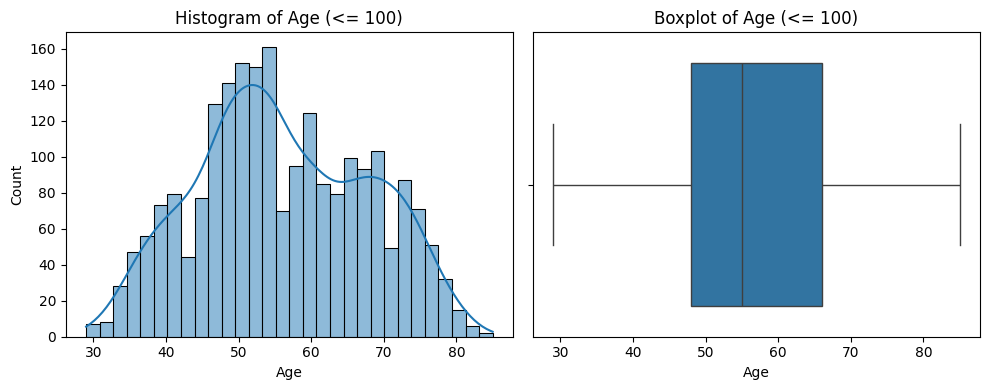

In [81]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_cleaned['Age'], bins=30, kde=True)
plt.title('Histogram of Age (<= 100)')

plt.subplot(1,2,2)
sns.boxplot(x=df_cleaned['Age'])
plt.title('Boxplot of Age (<= 100)')

plt.tight_layout()
plt.show()

In [84]:
# Kiểm tra số dòng trùng lặp
num_duplicates = df_cleaned.duplicated().sum()
print(f"Số dòng trùng lặp: {num_duplicates}")

# Nếu muốn xem các dòng trùng lặp
duplicates = df_cleaned[df_cleaned.duplicated()]
print("Các dòng trùng lặp:")
print(duplicates)


Số dòng trùng lặp: 0
Các dòng trùng lặp:
Empty DataFrame
Columns: [Education, Marital_Status, Income, Kidhome, Teenhome, Recency, MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds, NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth, Response, Complain, Customer_Tenure, Age]
Index: []

[0 rows x 21 columns]


In [85]:
# Xóa các dòng trùng lặp, giữ lại dòng đầu tiên xuất hiện
df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)

print("Số dòng sau khi loại bỏ trùng:", len(df_cleaned))

Số dòng sau khi loại bỏ trùng: 2031


In [86]:
df_cleaned.to_csv("superstore_cleaned.csv", index = False)

In [87]:
df_cleaned.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Customer_Tenure,Age
0,Graduation,Divorced,84835.0,0,0,0,189,104,379,111,...,218,1,4,4,6,1,1,0,173,55
1,Graduation,Single,57091.0,0,0,0,464,5,64,7,...,37,1,7,3,7,5,1,0,174,64
2,Graduation,Married,67267.0,0,1,0,134,11,59,15,...,30,1,3,2,5,2,0,0,207,67
3,Graduation,Together,32474.0,1,1,0,10,0,1,0,...,0,1,1,0,2,7,0,0,31,58
4,Graduation,Single,21474.0,1,0,0,6,16,24,11,...,34,2,3,1,2,7,1,0,124,36


In [88]:

# Kích thước dataset
print(f'Shape: {df_cleaned.shape}')

# Kiểu dữ liệu và missing values
print(df_cleaned.info())
print(df_cleaned.isnull().sum())

# Kiểm tra giá trị âm ở các biến numeric
numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_cols:
    num_negative = (df_cleaned[col] < 0).sum()
    if num_negative > 0:
        print(f"Warning: {col} có {num_negative} giá trị âm còn lại.")

# Thống kê mô tả nhanh
print(df_cleaned.describe())

Shape: (2031, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2031 entries, 0 to 2030
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2031 non-null   object 
 1   Marital_Status       2031 non-null   object 
 2   Income               2031 non-null   float64
 3   Kidhome              2031 non-null   int64  
 4   Teenhome             2031 non-null   int64  
 5   Recency              2031 non-null   int64  
 6   MntWines             2031 non-null   int64  
 7   MntFruits            2031 non-null   int64  
 8   MntMeatProducts      2031 non-null   int64  
 9   MntFishProducts      2031 non-null   int64  
 10  MntSweetProducts     2031 non-null   int64  
 11  MntGoldProds         2031 non-null   int64  
 12  NumDealsPurchases    2031 non-null   int64  
 13  NumWebPurchases      2031 non-null   int64  
 14  NumCatalogPurchases  2031 non-null   int64  
 15  NumStorePurchases   

-------------

DATASET WATER QUALITY

In [3]:
df1 = pd.read_csv("waterQuality1.csv")
df1.info()
df1.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uraniu

,aluminium,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,viruses,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium
count,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000
mean,0.666158,0.161445,1.567715,0.042806,2.176831,0.247226,0.805857,0.771565,0.319665,0.328583,0.099450,9.818822,1.329961,0.005194,16.460299,2.920548,0.049685,0.147781,0.044673
std,1.265145,0.252590,1.216091,0.036049,2.567027,0.270640,0.653539,0.435373,0.329485,0.378096,0.058172,5.541331,0.573219,0.002967,17.687474,2.323009,0.028770,0.143551,0.026904
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040000,0.030000,0.560000,0.008000,0.100000,0.050000,0.090000,0.405000,0.000000,0.002000,0.048000,5.000000,1.000000,0.003000,2.170000,0.820000,0.020000,0.040000,0.020000
50%,0.070000,0.050000,1.190000,0.040000,0.530000,0.090000,0.750000,0.770000,0.220000,0.008000,0.102000,9.930000,1.420000,0.005000,7.740000,2.410000,0.050000,0.080000,0.050000
75%,0.280000,0.100000,2.480000,0.070000,4.240000,0.440000,1.390000,1.160000,0.610000,0.700000,0.151000,14.610000,1.760000,0.008000,29.480000,4.670000,0.070000,0.240000,0.070000
max,5.050000,1.050000,4.940000,0.130000,8.680000,0.900000,2.000000,1.500000,1.000000,1.000000,0.200000,19.830000,2.930000,0.010000,60.010000,7.990000,0.100000,0.500000,0.090000


In [4]:
df1.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [5]:
import pandas as pd

# Thay thế các giá trị không hợp lệ như '#NUM!' bằng NaN
df1['ammonia'] = pd.to_numeric(df1['ammonia'], errors='coerce')
# Chuyển đổi kiểu sang float
df1['ammonia'] = df1['ammonia'].astype(float)

# Thay thế các giá trị không hợp lệ như '#NUM!' bằng NaN
df1['is_safe'] = pd.to_numeric(df1['is_safe'], errors='coerce')
df1['is_safe'] = df1['is_safe'].astype('Int64')  # Chuyển sang int
# Kiểm tra kết quả
print(df1)



      aluminium  ammonia  arsenic  barium  cadmium  chloramine  chromium  \
0          1.65     9.08     0.04    2.85    0.007        0.35      0.83   
1          2.32    21.16     0.01    3.31    0.002        5.28      0.68   
2          1.01    14.02     0.04    0.58    0.008        4.24      0.53   
3          1.36    11.33     0.04    2.96    0.001        7.23      0.03   
4          0.92    24.33     0.03    0.20    0.006        2.67      0.69   
...         ...      ...      ...     ...      ...         ...       ...   
7994       0.05     7.78     0.00    1.95    0.040        0.10      0.03   
7995       0.05    24.22     0.02    0.59    0.010        0.45      0.02   
7996       0.09     6.85     0.00    0.61    0.030        0.05      0.05   
7997       0.01    10.00     0.01    2.00    0.000        2.00      0.00   
7998       0.04     6.85     0.01    0.70    0.030        0.05      0.01   

      copper  flouride  bacteria  ...   lead  nitrates  nitrites  mercury  \
0       0.

,Total,Percent
ammonia,3,0.000375
is_safe,3,0.000375
aluminium,0,0.000000
barium,0,0.000000
arsenic,0,0.000000


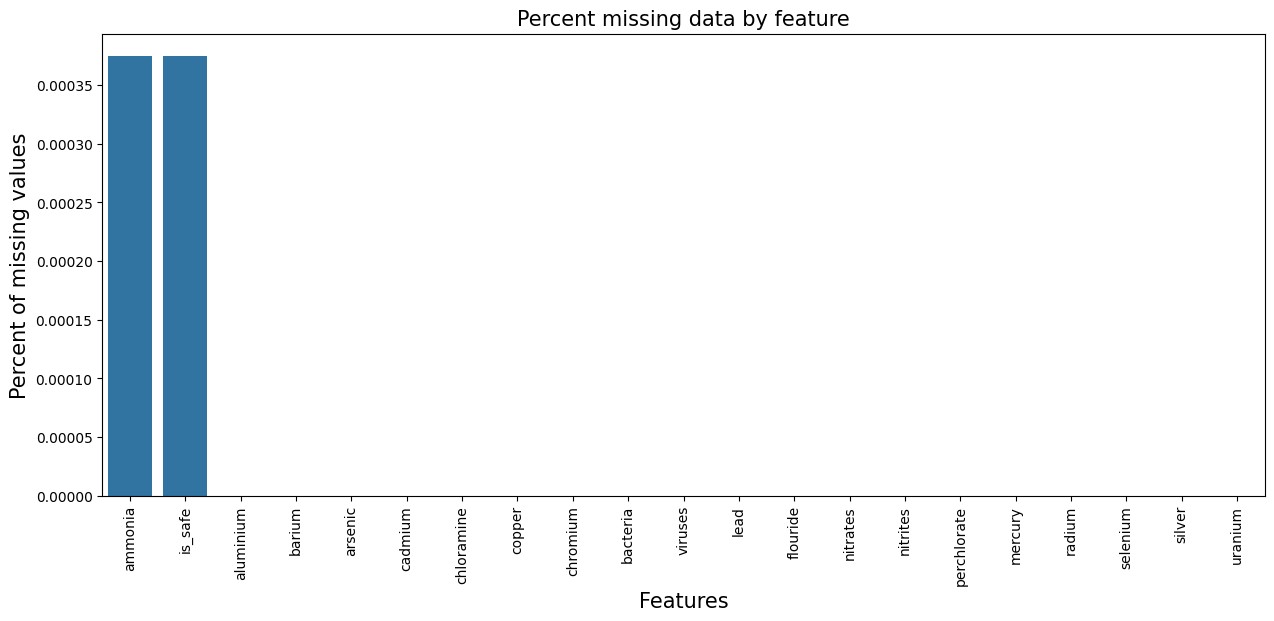

In [6]:
total = df1.isnull().sum().sort_values(ascending=False)
percent = (df1.isnull().sum()/df1.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
f, ax = plt.subplots(figsize=(15, 6))
plt.xticks(rotation=90)
sns.barplot(x=missing_data.index, y=missing_data['Percent'])
plt.xlabel('Features', fontsize=15)
plt.ylabel('Percent of missing values', fontsize=15)
plt.title('Percent missing data by feature', fontsize=15)
missing_data.head()

In [7]:
# Xóa các dòng có giá trị thiếu ở cột
df1 = df1.dropna(subset=['ammonia']).reset_index(drop=True)
df1 = df1.dropna(subset=['is_safe']).reset_index(drop=True)
df1.isnull().sum()

aluminium      0
ammonia        0
arsenic        0
barium         0
cadmium        0
chloramine     0
chromium       0
copper         0
flouride       0
bacteria       0
viruses        0
lead           0
nitrates       0
nitrites       0
mercury        0
perchlorate    0
radium         0
selenium       0
silver         0
uranium        0
is_safe        0
dtype: int64

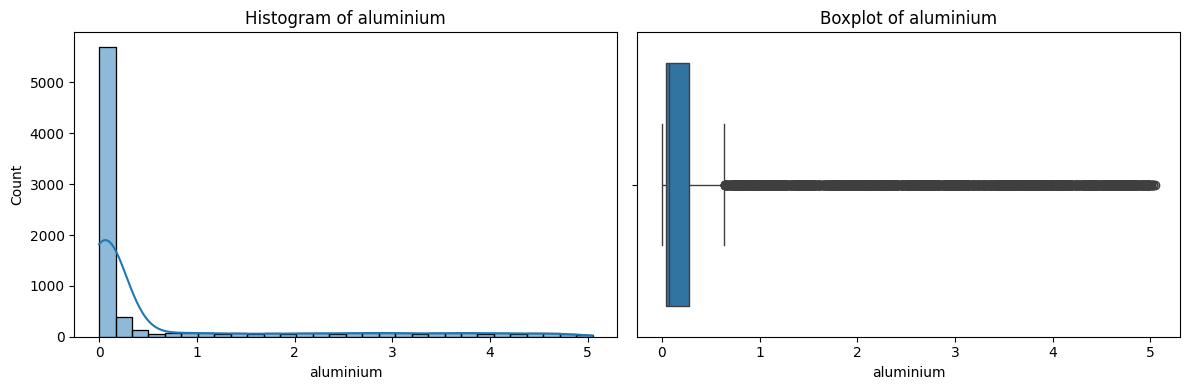

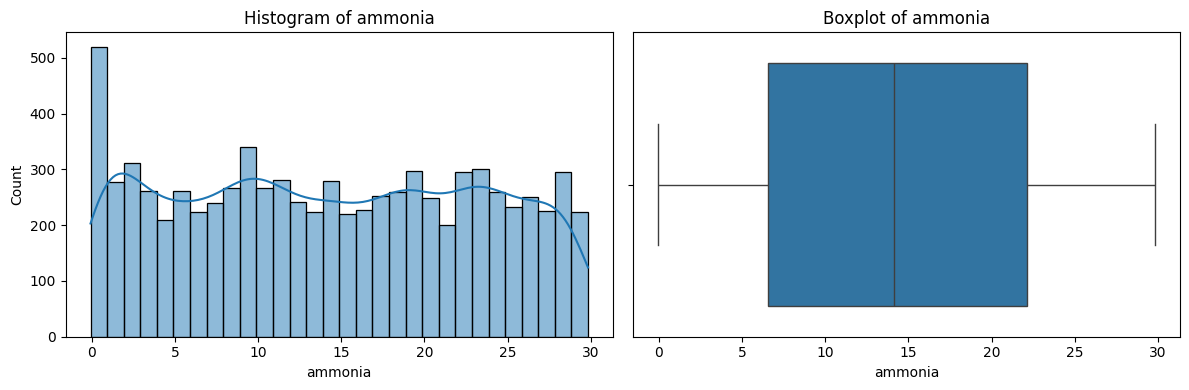

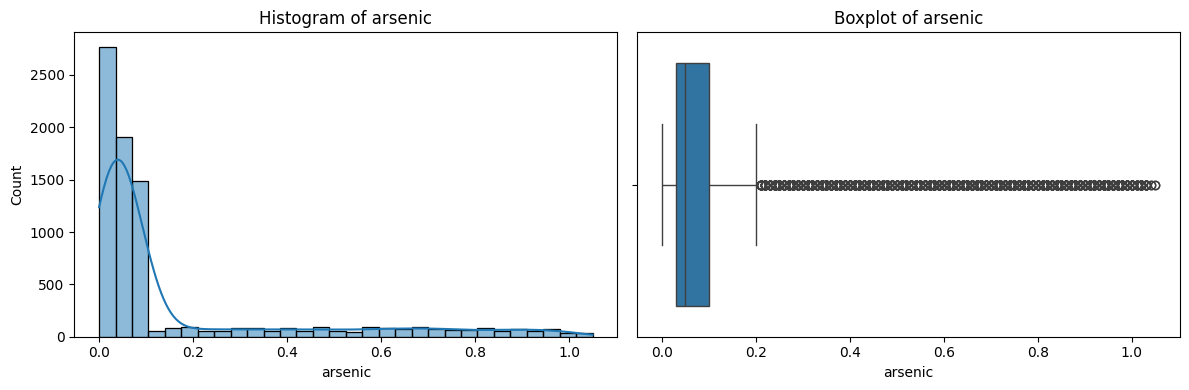

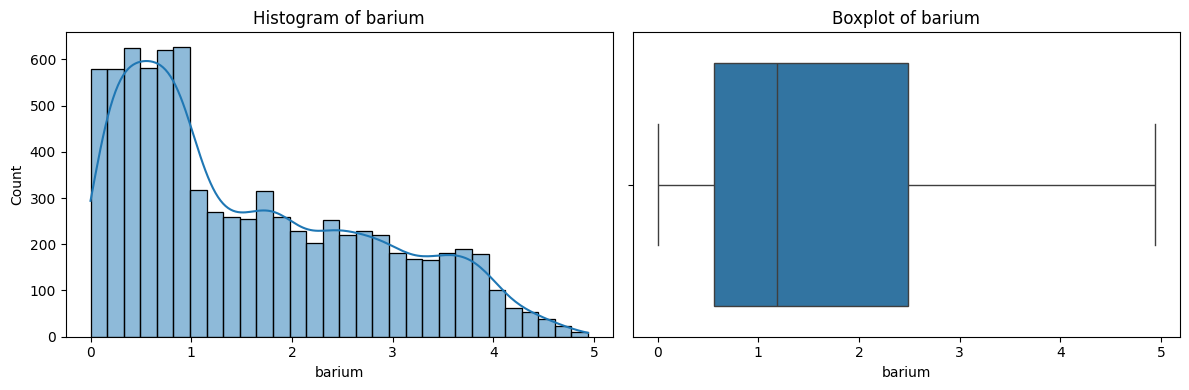

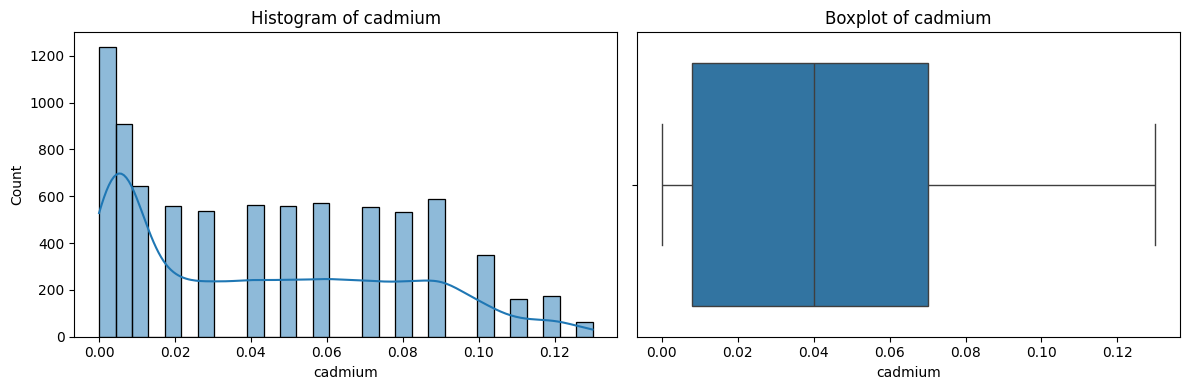

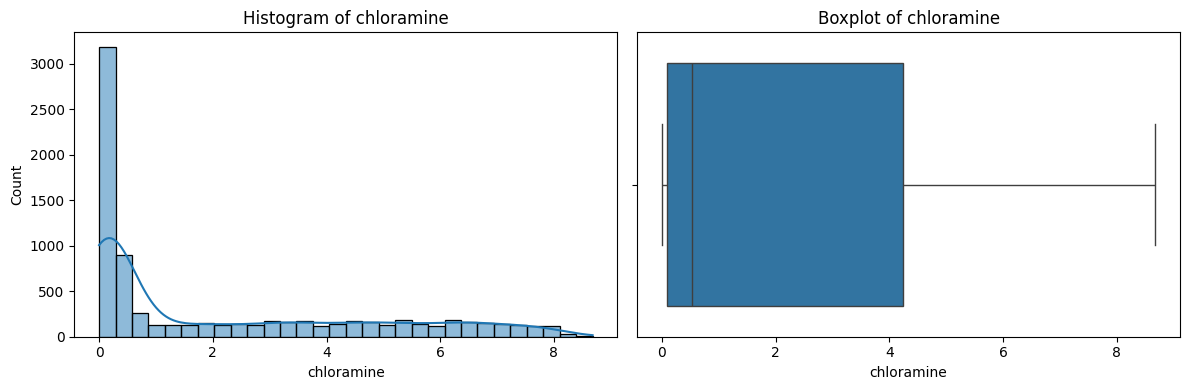

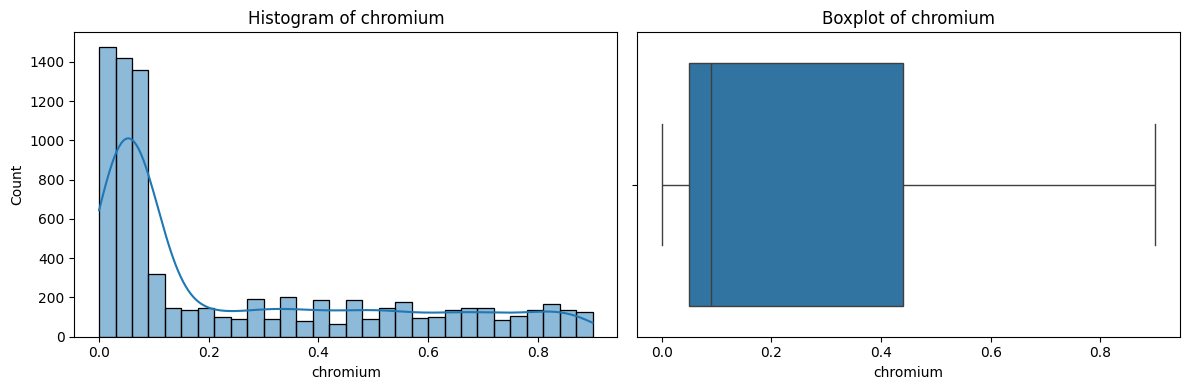

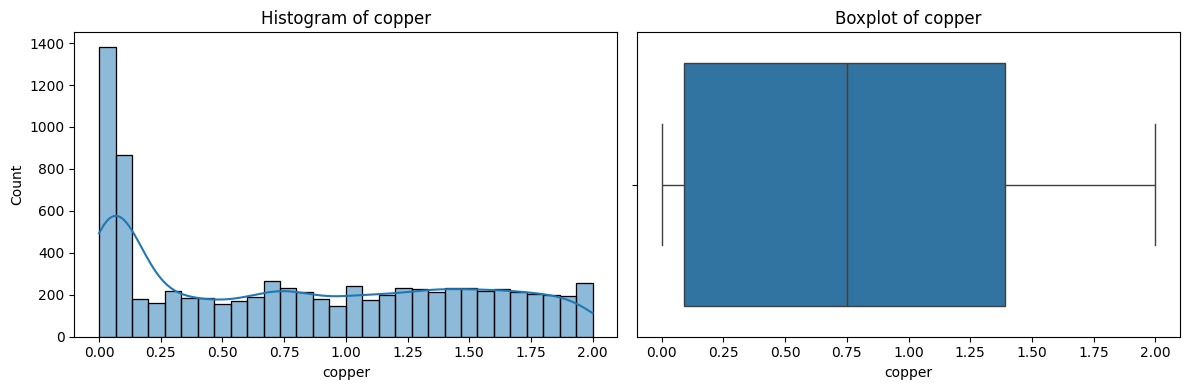

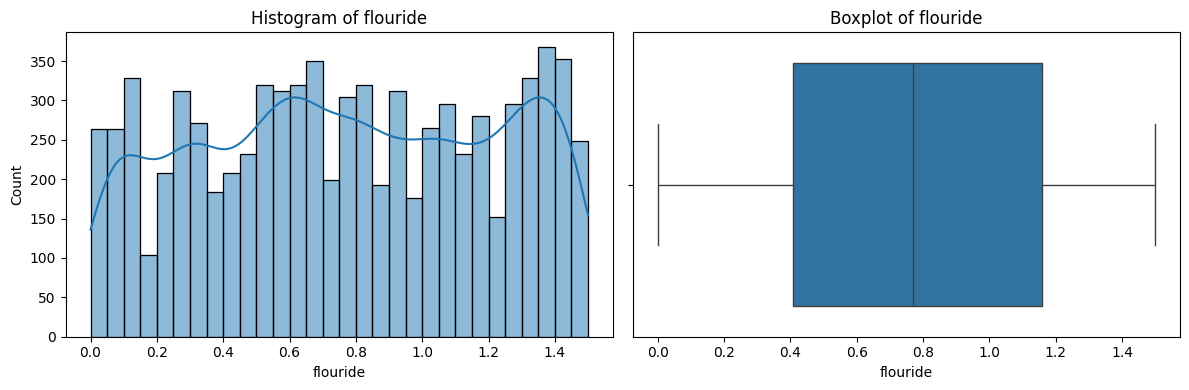

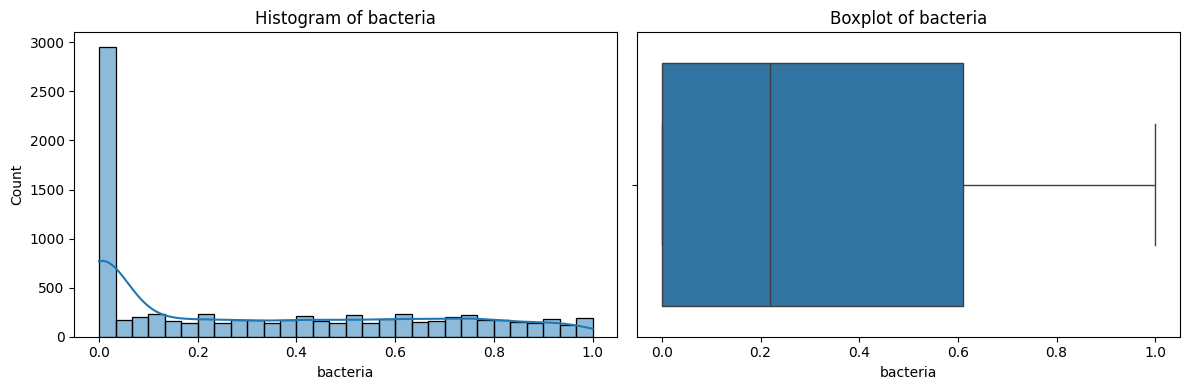

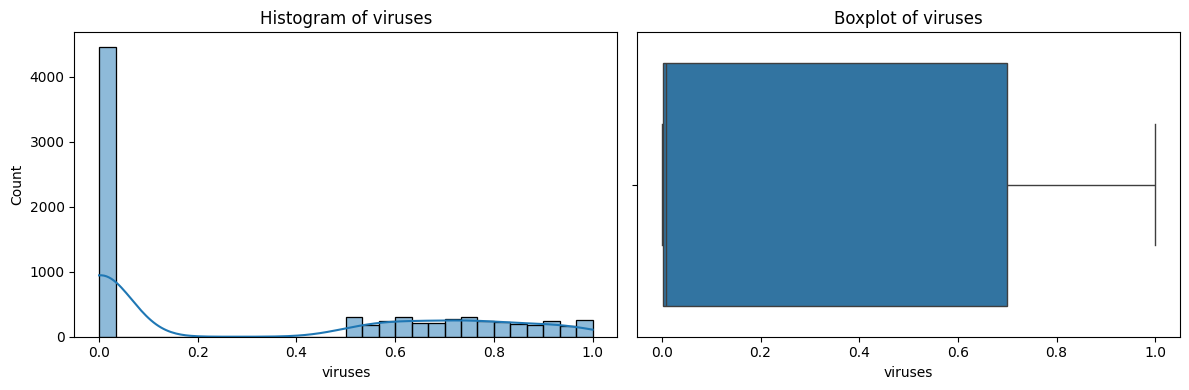

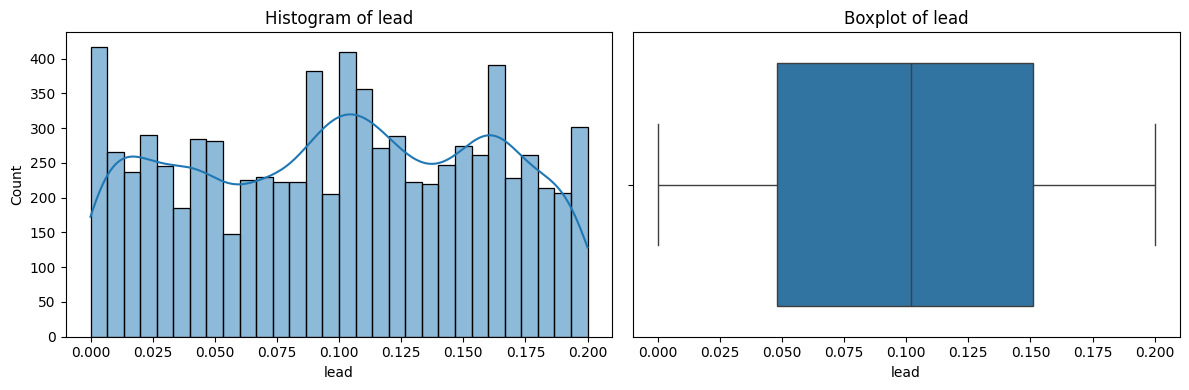

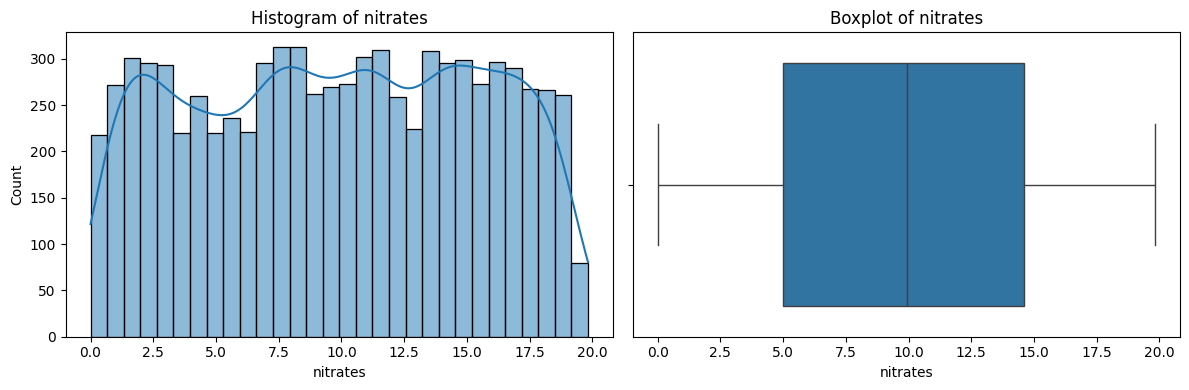

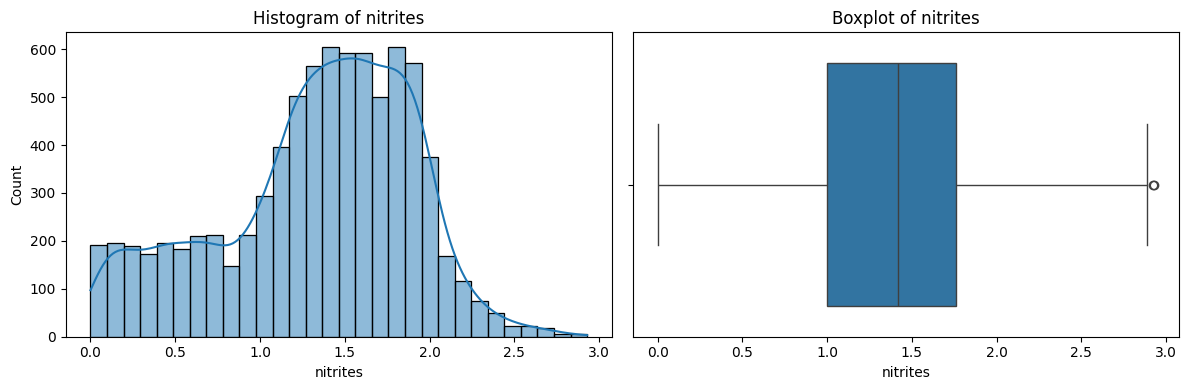

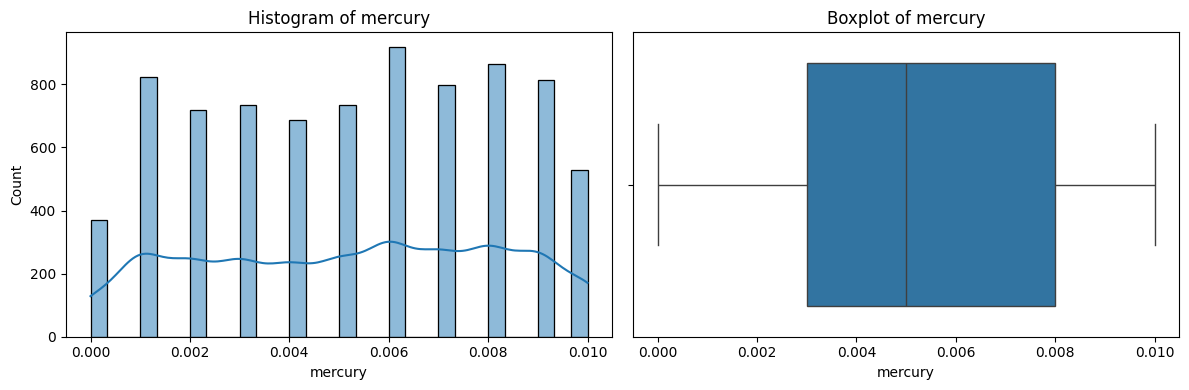

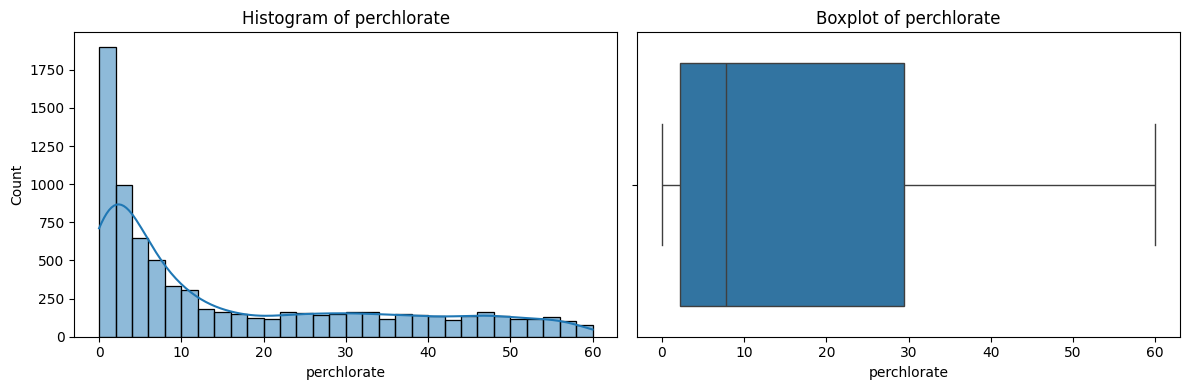

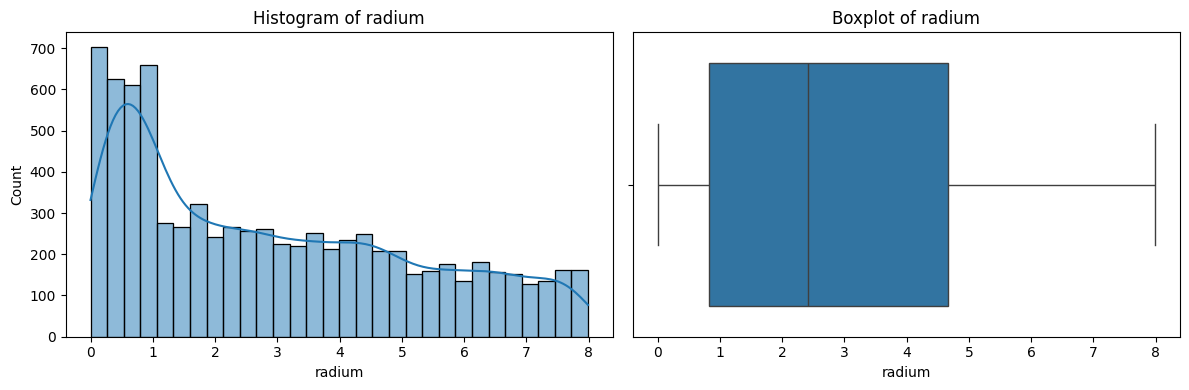

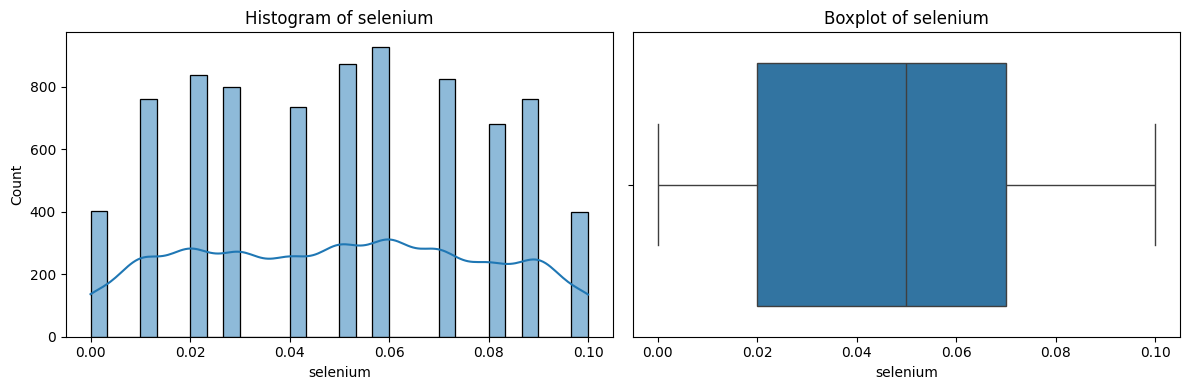

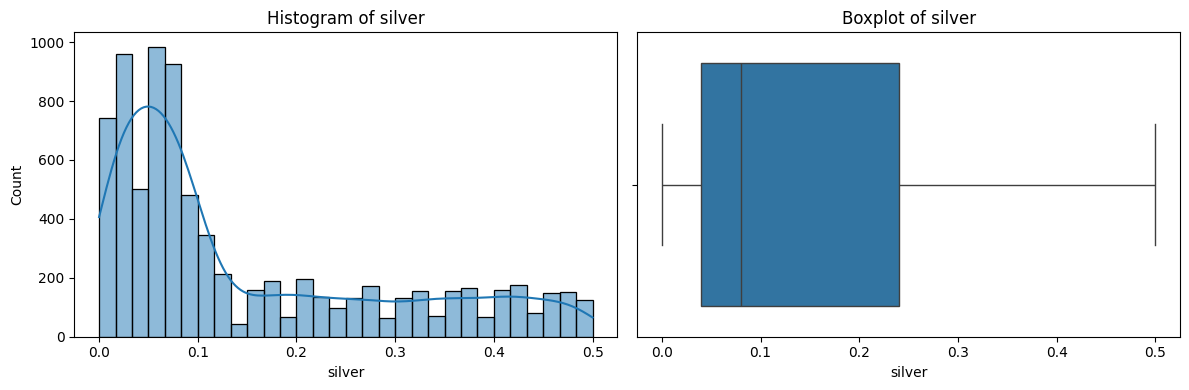

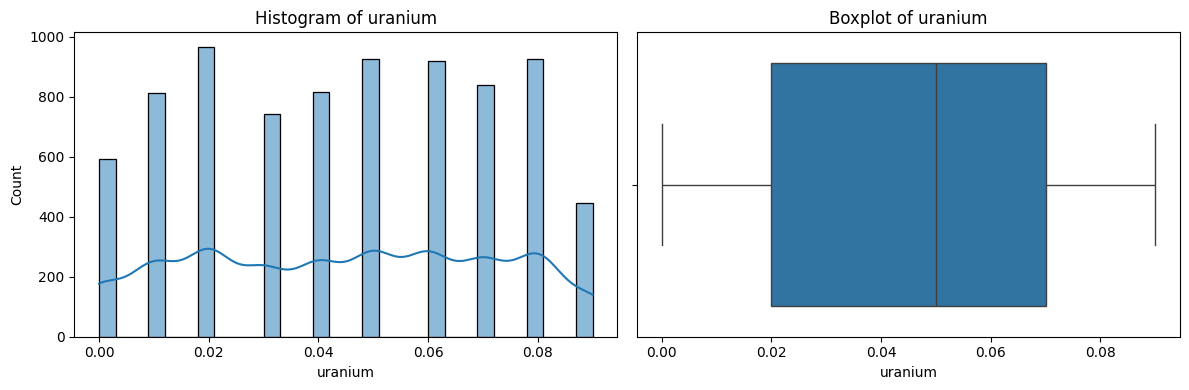

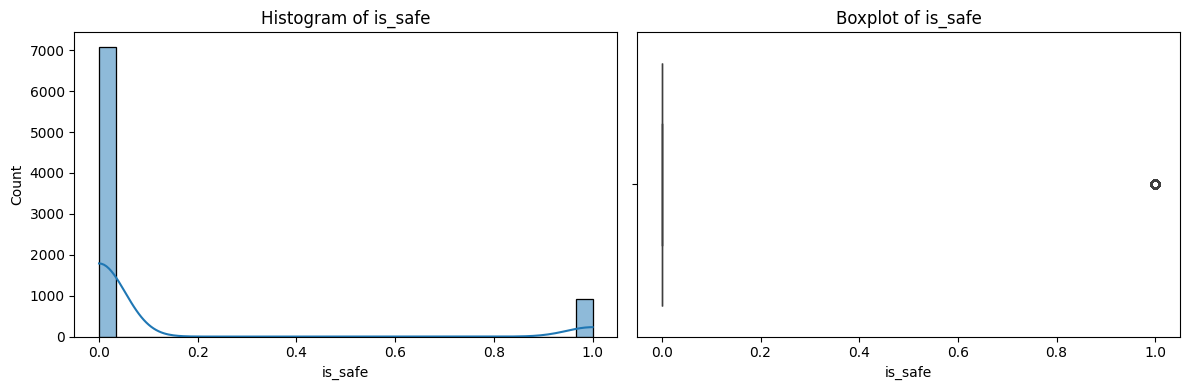

In [8]:
# Danh sách các cột numeric (float + int)
numeric_cols = df1.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Vẽ histogram + boxplot cho từng biến numeric
for col in numeric_cols:
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    sns.histplot(df1[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df1[col])
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

Eliminate Ammonia < 0

In [9]:
# Kiểm tra số dòng ban đầu
print(f"Số dòng trước khi lọc: {len(df1)}")

# Lọc giữ lại các dòng có ammonia >= 0
df_cleaned1 = df1[df1['ammonia'] >= 0].copy()

# Kiểm tra số dòng sau khi lọc
print(f"Số dòng sau khi loại bỏ ammonia: {len(df_cleaned1)}")

Số dòng trước khi lọc: 7996
Số dòng sau khi loại bỏ ammonia: 7986


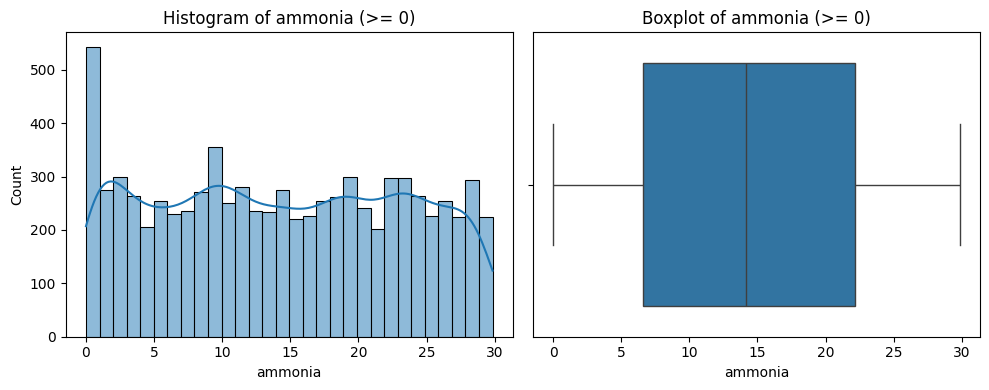

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_cleaned1['ammonia'], bins=30, kde=True)
plt.title('Histogram of ammonia (>= 0)')

plt.subplot(1,2,2)
sns.boxplot(x=df_cleaned1['ammonia'])
plt.title('Boxplot of ammonia (>= 0)')

plt.tight_layout()
plt.show()

In [11]:
# Kiểm tra số dòng trùng lặp
num_duplicates = df_cleaned1.duplicated().sum()
print(f"Số dòng trùng lặp: {num_duplicates}")

# Nếu muốn xem các dòng trùng lặp
duplicates = df_cleaned1[df_cleaned1.duplicated()]
print("Các dòng trùng lặp:")
print(duplicates)


Số dòng trùng lặp: 0
Các dòng trùng lặp:
Empty DataFrame
Columns: [aluminium, ammonia, arsenic, barium, cadmium, chloramine, chromium, copper, flouride, bacteria, viruses, lead, nitrates, nitrites, mercury, perchlorate, radium, selenium, silver, uranium, is_safe]
Index: []

[0 rows x 21 columns]


In [39]:
df_cleaned1.to_csv("water_quality_cleaned.csv", index = False)